# 01 · Linear Regression

*A Tour of Machine Learning* reworks material from Elie Rouphael's own MADIS Machine
Learning Workshop into eleven standalone notebooks, one idea each, so every method can
be read (and run) on its own. This chapter is the simplest and most fundamental one:
fitting a straight line — or a plane — through data with **linear regression**.

**Objectives:** fit simple and multiple linear regression with scikit-learn, read the
coefficients as rates of change, and judge the fit with $R^2$.

## 1. The model: a line plus noise

We have $n$ observations. Observation $i$ has an input $x_i$ and an output $y_i$. Below, $x_i$ is the weight of car $i$ in kg, $y_i$ is its CO2 emission rate in g/km, and $n = 36$. The model says that the output is a straight-line function of the input, plus a random error:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad i = 1, \dots, n$$

- $\beta_0$ is the **intercept**: the height of the line at $x = 0$. It has the units of $y$ (g/km).
- $\beta_1$ is the **slope**: the change in $y$ when $x$ grows by one unit (g/km per kg).
- $\varepsilon_i$ is the **error**: everything that pushes $y_i$ off the line and is not captured by $x_i$ (engine tuning, fuel type, measurement error). It averages zero.

The true $\beta_0$ and $\beta_1$ are unknown; a hat, as in $\hat\beta_0$ and $\hat\beta_1$, marks an estimate computed from data. Any candidate line gives each point a prediction $\hat y_i = \hat\beta_0 + \hat\beta_1 x_i$ and a **residual** $e_i = y_i - \hat y_i$: the vertical gap between the point and the line, positive above the line and negative below.

A good line makes the residuals small. Simply adding them fails, because positive and negative gaps cancel. **Least squares** squares each residual first, then adds:

$$S(\beta_0, \beta_1) = \sum_{i=1}^{n} \big(y_i - \beta_0 - \beta_1 x_i\big)^2$$

$S$ turns every candidate pair $(\beta_0, \beta_1)$ into one number, the total squared miss, and the best line is the pair that makes it smallest. Squaring punishes a gap of 2 four times as hard as a gap of 1. It also makes $S$ a smooth bowl in the two coefficients, so calculus can find its lowest point exactly.

## 2. Deriving the best line

At the bottom of a smooth bowl the slope is zero in every direction (chapter 02 develops this idea). So we set both partial derivatives of $S$ to zero. The chain rule gives the derivative of a square $(\dots)^2$ as $2(\dots)$ times the derivative of what is inside.

**The intercept.** The inside, $y_i - \beta_0 - \beta_1 x_i$, has derivative $-1$ with respect to $\beta_0$:

$$\frac{\partial S}{\partial \beta_0} = -2\sum_{i} \big(y_i - \beta_0 - \beta_1 x_i\big) = 0$$

Divide by $-2n$ and write $\bar x = \frac1n\sum_i x_i$ and $\bar y = \frac1n\sum_i y_i$ for the two means:

$$\bar y - \hat\beta_0 - \hat\beta_1 \bar x = 0 \quad\Longrightarrow\quad \hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

In words: the residuals sum to zero, and the fitted line passes through the centre of the cloud, the point $(\bar x, \bar y)$.

**The slope.** The inside has derivative $-x_i$ with respect to $\beta_1$:

$$\frac{\partial S}{\partial \beta_1} = -2\sum_{i} x_i\big(y_i - \beta_0 - \beta_1 x_i\big) = 0$$

Substitute $\beta_0 = \bar y - \beta_1 \bar x$. The bracket becomes $(y_i - \bar y) - \beta_1 (x_i - \bar x)$, so

$$\sum_{i} x_i (y_i - \bar y) = \hat\beta_1 \sum_{i} x_i (x_i - \bar x)$$

One last step. Deviations from a mean always sum to zero, $\sum_i (y_i - \bar y) = 0$, so subtracting $\bar x$ times that sum changes nothing: $\sum_i x_i(y_i - \bar y) = \sum_i (x_i - \bar x)(y_i - \bar y)$. The same trick works on the right-hand side. Therefore

$$\hat\beta_1 = \frac{\sum_i (x_i - \bar x)(y_i - \bar y)}{\sum_i (x_i - \bar x)^2} = \frac{\mathrm{cov}(x, y)}{\mathrm{var}(x)}$$

The last form divides the top and the bottom by $n$, which turns the sums into the covariance of $x$ and $y$ and the variance of $x$. Read it as: the slope is how strongly $x$ and $y$ move together, measured in units of how much $x$ varies on its own. If $y$ tends to sit above its mean whenever $x$ sits above its mean, the covariance is positive and the line rises.

## 3. A line through four points, by hand

Take four points: $(1, 1)$, $(2, 3)$, $(3, 2)$, $(4, 4)$. The means are $\bar x = 10/4 = 2.5$ and $\bar y = 10/4 = 2.5$.

| $i$ | $x_i$ | $y_i$ | $x_i - \bar x$ | $y_i - \bar y$ | $(x_i - \bar x)(y_i - \bar y)$ | $(x_i - \bar x)^2$ |
|---|---|---|---|---|---|---|
| 1 | 1 | 1 | −1.5 | −1.5 | 2.25 | 2.25 |
| 2 | 2 | 3 | −0.5 | 0.5 | −0.25 | 0.25 |
| 3 | 3 | 2 | 0.5 | −0.5 | −0.25 | 0.25 |
| 4 | 4 | 4 | 1.5 | 1.5 | 2.25 | 2.25 |
| **sum** | | | 0 | 0 | **4** | **5** |

So $\hat\beta_1 = 4/5 = 0.8$ and $\hat\beta_0 = 2.5 - 0.8 \times 2.5 = 0.5$. The fitted line is $\hat y = 0.5 + 0.8\,x$. Now the predictions and residuals:

| $x_i$ | $y_i$ | $\hat y_i$ | $e_i$ | $e_i^2$ | $x_i e_i$ |
|---|---|---|---|---|---|
| 1 | 1 | 1.3 | −0.3 | 0.09 | −0.3 |
| 2 | 3 | 2.1 | 0.9 | 0.81 | 1.8 |
| 3 | 2 | 2.9 | −0.9 | 0.81 | −2.7 |
| 4 | 4 | 3.7 | 0.3 | 0.09 | 1.2 |
| **sum** | | | **0** | **1.8** | **0** |

The two zeros are the two equations of Section 2: $\sum_i e_i = 0$ (the $\beta_0$ equation) and $\sum_i x_i e_i = 0$ (the $\beta_1$ equation). The total squared miss is $S = 1.8$, and no other line does better; for instance, the line $\hat y = x$ leaves residuals $0, 1, -1, 0$ and $S = 2$.

## 4. Several inputs: matrices, projection and R²

With $p$ inputs (below, $p = 2$) the model is $y_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_p x_{ip} + \varepsilon_i$, where $x_{ij}$ is input $j$ of observation $i$. In matrix form:

- $y$ ($n \times 1$) holds the outputs, $\varepsilon$ ($n \times 1$) the errors, $\beta$ ($(p+1) \times 1$) the coefficients.
- $X$ ($n \times (p+1)$) is the **design matrix**. Row $i$ is $(1, x_{i1}, \dots, x_{ip})$; the column of ones carries the intercept.

$$y = X\beta + \varepsilon$$

The sum of squared residuals is $S(\beta) = (y - X\beta)^\top (y - X\beta)$. Setting its gradient $-2X^\top(y - X\beta)$ to zero repeats Section 2 for all coefficients at once and gives the **normal equations**:

$$X^\top X\,\hat\beta = X^\top y \qquad\Longrightarrow\qquad \hat\beta = (X^\top X)^{-1} X^\top y$$

The inverse exists as long as no input is an exact linear combination of the others. Row $j$ of $X^\top(y - X\hat\beta) = 0$ reads $\sum_i x_{ij} e_i = 0$: the residuals are orthogonal to every column of $X$. With $p = 1$ these are exactly the two zeros in the table above.

**Geometric reading.** Think of $y$ as one arrow in $n$-dimensional space, one coordinate per observation. As $\beta$ varies, $X\beta$ sweeps out a flat subspace: every prediction the model can produce. Least squares picks the point $\hat y = X\hat\beta$ of that subspace closest to $y$: the foot of the perpendicular, where the residual $e = y - \hat y$ meets the subspace at a right angle. So $\hat y$ is the **orthogonal projection** of $y$ onto the columns of $X$.

**$R^2$.** $SS_{\mathrm{tot}} = \sum_i (y_i - \bar y)^2$ is the total spread of $y$ around its mean, the squared miss of the flat line $\hat y = \bar y$. $SS_{\mathrm{res}} = \sum_i (y_i - \hat y_i)^2$ is the spread left after the fit.

$$R^2 = 1 - \frac{SS_{\mathrm{res}}}{SS_{\mathrm{tot}}}$$

Because the residual is perpendicular to the fitted part, Pythagoras gives $SS_{\mathrm{tot}} = \sum_i (\hat y_i - \bar y)^2 + SS_{\mathrm{res}}$ (when the model has an intercept). So $R^2$ lies between 0 and 1 and is the fraction of the variance of $y$ that the model explains. In the example, $SS_{\mathrm{tot}} = 2.25 + 0.25 + 0.25 + 2.25 = 5$ and $SS_{\mathrm{res}} = 1.8$, so $R^2 = 1 - 1.8/5 = 0.64$. With a single input, $R^2$ equals the squared correlation of $x$ and $y$: here $r = 4/\sqrt{5 \times 5} = 0.8$ and $r^2 = 0.64$. Adding an input enlarges the subspace, so $SS_{\mathrm{res}}$ can only shrink: $R^2$ never falls when an input is added, even a useless one.

**Reading the coefficients.** In the multiple model, $\beta_j$ is the change in the prediction when $x_j$ grows by one unit **with all the other inputs held fixed**.

**Assumptions.** Least squares can always be computed; reading its output as true effects with trustworthy error bars relies on:

1. Linearity: the average of $y$ is linear in the inputs.
2. Independent errors across observations.
3. Constant error variance at every input value.
4. Zero-mean errors at every input value (no omitted cause correlated with the inputs).
5. No perfect collinearity, so $X^\top X$ is invertible.
6. For exact small-sample intervals, normally distributed errors.

**In the code below.** `X1` is the $36 \times 1$ matrix of weights and `y` the CO2 vector. `LinearRegression` adds the column of ones itself and solves least squares: `b0` is $\hat\beta_0$, `b1` is $\hat\beta_1$, and `simple.score(X1, y)` returns $R^2$. `X2` has two columns, `Weight` and `Volume`, so `multi` solves the normal equations with $p = 2$, giving `b0_m`, `b_w` and `b_v`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import mlutils
mlutils.set_style()
pd.set_option("display.precision", 3)

## 5. The data

Thirty-six cars, each with an engine displacement (`Volume`, cm3), a `Weight` (kg),
and a measured `CO2` emission rate (g/km). This is a real toy dataset used to teach
regression: two candidate causes, one outcome, and a small enough table to look at
directly.

In [2]:
df = pd.read_csv("data/data.csv")
df.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


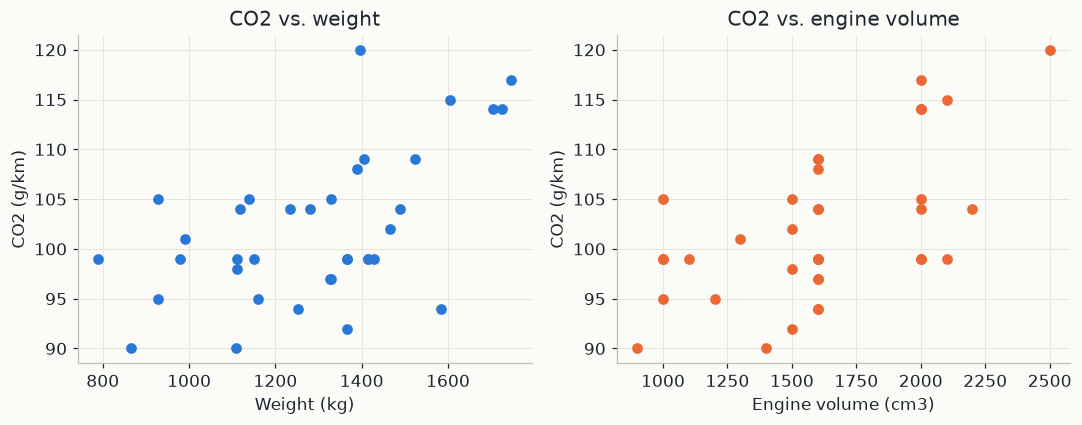

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df["Weight"], df["CO2"], color=mlutils.BLUE)
axes[0].set(xlabel="Weight (kg)", ylabel="CO2 (g/km)", title="CO2 vs. weight")
axes[1].scatter(df["Volume"], df["CO2"], color=mlutils.ORANGE)
axes[1].set(xlabel="Engine volume (cm3)", ylabel="CO2 (g/km)", title="CO2 vs. engine volume")
fig.tight_layout()

Both look like they carry *some* signal, and both are noisy — cars of similar weight
have quite different emissions. That's normal: `CO2` also depends on things this table
doesn't record (engine tuning, fuel type, driving cycle). Regression finds the best
straight-line summary anyway.

## 6. Simple linear regression

A simple linear regression models one predictor:

$$\widehat{\text{CO2}} = \beta_0 + \beta_1 \cdot \text{Weight}$$

scikit-learn's `LinearRegression` fits $\beta_0, \beta_1$ by ordinary least squares,
with exactly the formulas derived in Section 2.

In [4]:
X1 = df[["Weight"]].values
y = df["CO2"].values

simple = LinearRegression().fit(X1, y)
b1 = simple.coef_[0]
b0 = simple.intercept_
r2_simple = simple.score(X1, y)
print(f"CO2 = {b0:.2f} + {b1:.4f} * Weight")
print(f"R2 = {r2_simple:.3f}")

CO2 = 80.06 + 0.0170 * Weight
R2 = 0.305


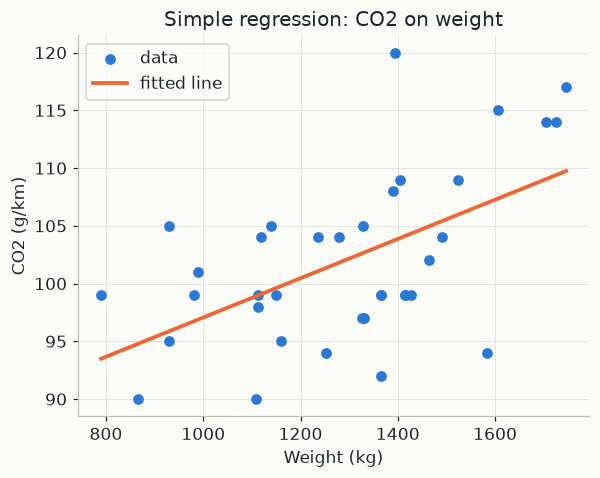

In [5]:
xs = np.linspace(df["Weight"].min(), df["Weight"].max(), 100)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["Weight"], df["CO2"], color=mlutils.BLUE, label="data")
ax.plot(xs, simple.predict(xs.reshape(-1, 1)), color=mlutils.ORANGE, lw=2.5, label="fitted line")
ax.set(xlabel="Weight (kg)", ylabel="CO2 (g/km)", title="Simple regression: CO2 on weight")
ax.legend()

Read the slope as a rate: every extra kilogram of car adds about
$\beta_1 \approx 0.017$ g/km of CO2. The intercept, $\beta_0 \approx 80$, is what the
line predicts at zero weight — not physically meaningful here, just where the line
crosses the axis. $R^2$ says how much of the variance in CO2 the line explains; the
rest is unexplained noise or missing predictors.

## 7. Multiple linear regression

Add `Volume` as a second predictor:

$$\widehat{\text{CO2}} = \beta_0 + \beta_1 \cdot \text{Weight} + \beta_2 \cdot \text{Volume}$$

Geometrically this fits a *plane* through the 3D cloud of (Weight, Volume, CO2) points
instead of a line through a 2D cloud.

In [6]:
X2 = df[["Weight", "Volume"]].values
multi = LinearRegression().fit(X2, y)
b_w, b_v = multi.coef_
b0_m = multi.intercept_
r2_multi = multi.score(X2, y)
print(f"CO2 = {b0_m:.2f} + {b_w:.4f} * Weight + {b_v:.4f} * Volume")
print(f"R2 = {r2_multi:.3f}  (simple regression was {r2_simple:.3f})")

CO2 = 79.69 + 0.0076 * Weight + 0.0078 * Volume
R2 = 0.377  (simple regression was 0.305)


$R^2$ improved once `Volume` is added. Section 4 showed that $R^2$ can never fall when
an input is added, so a rise alone proves little; here the gain is clear, a sign that
engine size carries information about emissions that weight alone doesn't. Each coefficient is now a **partial** effect —
the change in predicted CO2 per unit of one predictor, *holding the other fixed*. That
is a different (usually smaller) number than the simple-regression slope, because part
of what weight "explained" alone is now shared with volume.

In [7]:
# A hypothetical mid-size car: 1300 kg, 1300 cm3 engine
example = pd.DataFrame({"Weight": [1300], "Volume": [1300]})
pred = multi.predict(example[["Weight", "Volume"]])
print(f"predicted CO2 for a 1300 kg / 1300 cm3 car: {pred[0]:.1f} g/km")

predicted CO2 for a 1300 kg / 1300 cm3 car: 99.7 g/km


C:\Users\elier\OneDrive\Desktop\MADIS Machine Learning Workshop\course_venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## Exercises

### Exercise 1: Standardised coefficients
`Weight` and `Volume` are on different scales, so their raw coefficients aren't
directly comparable as "which matters more". Standardise both predictors (subtract
the mean, divide by the standard deviation) before fitting, and compare the resulting
coefficients.

<details><summary>Solution</summary>

```python
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(df[["Weight", "Volume"]])
std_model = LinearRegression().fit(Xs, y)
print(std_model.coef_)  # now directly comparable: larger |coef| = stronger standardised effect
```
</details>

### Exercise 2: Residuals
Plot the residuals ($y - \hat y$) of the multiple regression against the fitted
values. Is there a pattern, or do they look like unstructured noise?

<details><summary>Solution</summary>

```python
resid = y - multi.predict(X2)
plt.scatter(multi.predict(X2), resid)
plt.axhline(0, color="k", lw=1)
plt.xlabel("fitted CO2"); plt.ylabel("residual")
```
With only 36 points the pattern is hard to judge by eye, which is itself a lesson:
diagnostics need enough data to be trustworthy.
</details>

## Key takeaways

- Linear regression fits the line (or plane, or hyperplane) that minimises squared
  residuals; scikit-learn's `LinearRegression` does this in closed form.
- A simple-regression coefficient is a *marginal* effect; a multiple-regression
  coefficient is a *partial* effect, holding the other predictors fixed — the two can
  differ once predictors are correlated with each other.
- $R^2$ measures explained variance, not correctness: a low $R^2$ can still be an
  honest, useful model of a genuinely noisy process.